# **1. Perkenalan Dataset**


# Eksperimen Preprocessing Data - Bank Customer Churn Prediction
* **Nama**: Rudy Wijaya
* **Dataset**: Bank Customer Churn (`Churn_Modelling.csv`) 
  https://www.kaggle.com/datasets/shrutimechlearn/churn-modelling
* **Objektif**: Melakukan eksplorasi data (EDA) dan preprocessing untuk menyiapkan dataset yang siap digunakan pada pelatihan model machine learning dengan target akurasi tinggi.

# **2. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from typing import List
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# **3. Memuat Dataset**

In [2]:
# Memuat dataset raw
data_path = "../Churn_Modelling.csv" if os.path.exists("../Churn_Modelling.csv") else "Churn_Modelling.csv"
df = pd.read_csv(data_path)

# Tampilkan 5 baris pertama
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# **4. Exploratory Data Analysis (EDA)**

In [3]:
# Informasi struktur dataset
print("--- Info Dataset ---")
df.info()

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
print("\n--- Summary Statistik ---")
df.describe()


--- Summary Statistik ---


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
})

print("--- Missing Values Summary ---")
display(missing_summary)

--- Missing Values Summary ---


,missing_count,missing_percentage
RowNumber,0,0.0
CustomerId,0,0.0
Surname,0,0.0
CreditScore,0,0.0
Geography,0,0.0
Gender,0,0.0
Age,0,0.0
Tenure,0,0.0
Balance,0,0.0
NumOfProducts,0,0.0


In [6]:
duplicate_count = df.duplicated().sum()
print(f"Jumlah duplicate records: {duplicate_count:,}")

Jumlah duplicate records: 0


In [7]:
cardinality_df = pd.DataFrame({
    "data_type": df.dtypes,
    "unique_count": df.nunique(),
    "unique_sample": [df[col].unique()[:3] for col in df.columns]
}).sort_values(by="unique_count")

print("--- Cardinality & Data Type Validation ---")
display(cardinality_df)

--- Cardinality & Data Type Validation ---


,data_type,unique_count,unique_sample
Gender,object,2,"[Female, Male]"
Exited,int64,2,"[1, 0]"
HasCrCard,int64,2,"[1, 0]"
IsActiveMember,int64,2,"[1, 0]"
Geography,object,3,"[France, Spain, Germany]"
NumOfProducts,int64,4,"[1, 3, 2]"
Tenure,int64,11,"[2, 1, 8]"
Age,int64,70,"[42, 41, 39]"
CreditScore,int64,460,"[619, 608, 502]"
Surname,object,2932,"[Hargrave, Hill, Onio]"


--- TABEL RINGKASAN SKEWNESS FITUR & MITIGASI ---


,Feature,Mean,Median,Skewness,Category,Action Required
0,Age,38.92,37.00,1.0113,High Skew,Log Transformation (np.log1p)
1,NumOfProducts,1.53,1.00,0.7456,Moderate Skew,Optional / StandardScaler
2,Balance,76485.89,97198.54,-0.1411,Ideal (Symmetric),StandardScaler Only
3,CreditScore,650.53,652.00,-0.0716,Ideal (Symmetric),StandardScaler Only
4,Tenure,5.01,5.00,0.0110,Ideal (Symmetric),StandardScaler Only
5,EstimatedSalary,100090.24,100193.92,0.0021,Ideal (Symmetric),StandardScaler Only


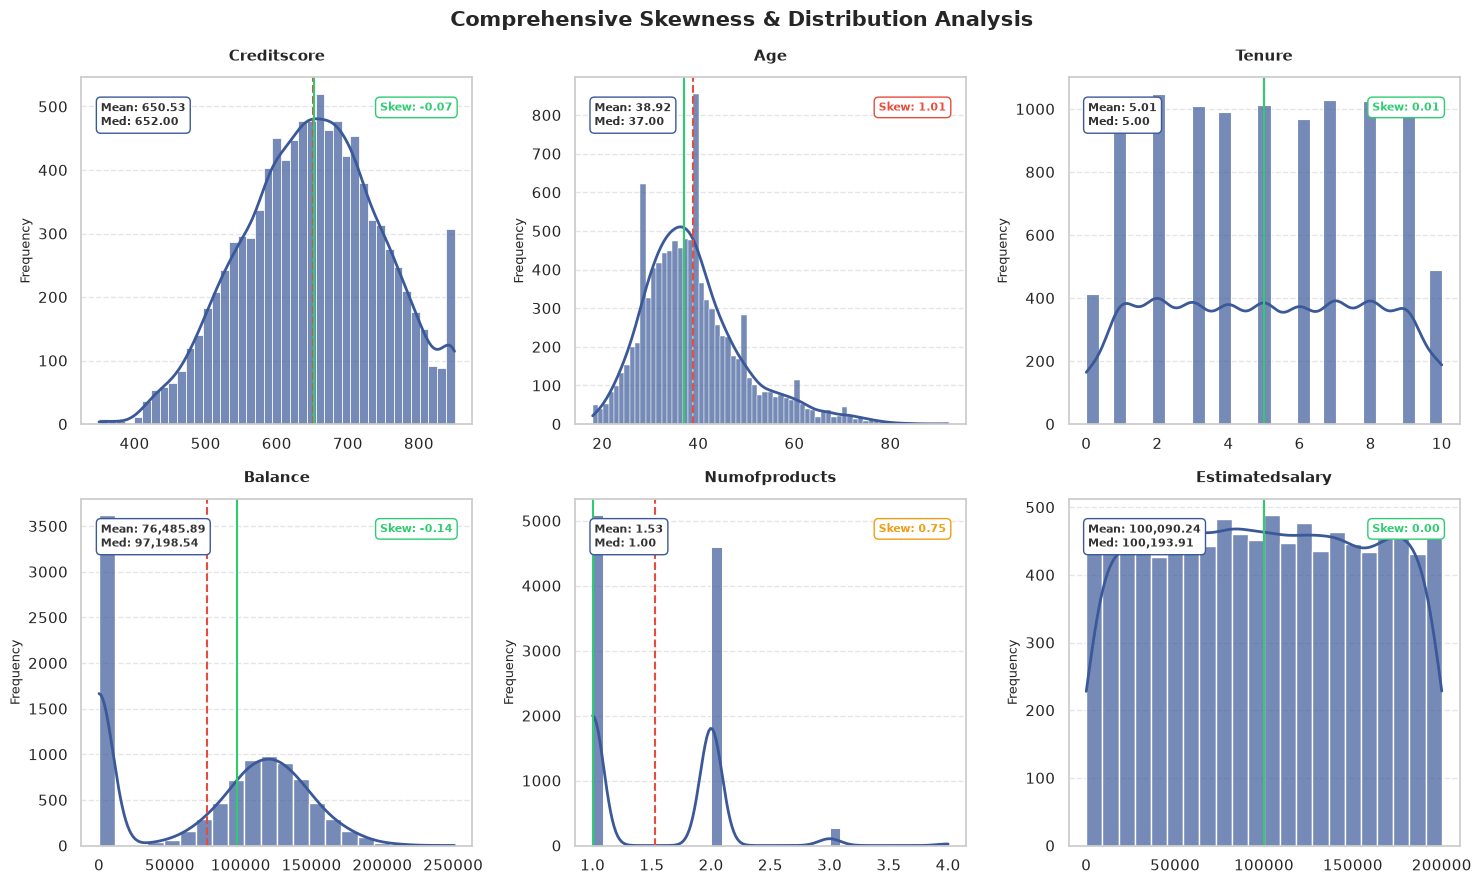

In [8]:
# Skewness Analysis & Distribution Dashboard
numeric_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

# Pembuatan Tabel Ringkasan Skewness & Mitigasi
skew_summary = []

for col in numeric_features:
    data = df[col].dropna()
    mean_val = data.mean()
    median_val = data.median()
    skew_val = data.skew()
    abs_skew = abs(skew_val)

    # Penentuan Kategori & Rekomendasi Tindakan
    if abs_skew > 1.0:
        category = "High Skew"
        action = "Log Transformation (np.log1p)"
    elif abs_skew > 0.5:
        category = "Moderate Skew"
        action = "Optional / StandardScaler"
    else:
        category = "Ideal (Symmetric)"
        action = "StandardScaler Only"

    skew_summary.append({
        "Feature": col,
        "Mean": round(mean_val, 2),
        "Median": round(median_val, 2),
        "Skewness": round(skew_val, 4),
        "Category": category,
        "Action Required": action
    })

# Konversi ke DataFrame dan urutkan berdasarkan absolute Skewness tertinggi
df_skew_summary = (
    pd.DataFrame(skew_summary)
    .sort_values(by="Skewness", key=abs, ascending=False)
    .reset_index(drop=True)
)

print("--- TABEL RINGKASAN SKEWNESS FITUR & MITIGASI ---")
display(df_skew_summary)

# Dashboard Visualisasi Skewness & Distribusi
def visualize_skewness_dashboard(data_frame: pd.DataFrame, features: List[str]) -> None:
    """
    Menampilkan dashboard distribusi & skewness untuk fitur numerik.
    """
    num_plots = len(features)
    cols = 3
    rows = (num_plots + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4.5))
    axes = axes.flatten() if num_plots > 1 else np.array([axes])

    for i, feature in enumerate(features):
        ax = axes[i]
        data = data_frame[feature].dropna()

        # Plot Histogram + KDE
        sns.histplot(
            data=data,
            kde=True,
            ax=ax,
            color="#3b5998",
            edgecolor="white",
            alpha=0.7,
            line_kws={"linewidth": 2, "color": "#1f2d3d"}
        )

        mean_val = data.mean()
        median_val = data.median()
        skew_val = data.skew()

        # Garis Indikator Mean & Median
        ax.axvline(mean_val, color="#e74c3c", linestyle="--", linewidth=1.5, label="Mean")
        ax.axvline(median_val, color="#2ecc71", linestyle="-", linewidth=1.5, label="Median")

        # Badge Statistik (Kiri Atas)
        stats_bbox = dict(boxstyle="round,pad=0.4", fc="white", ec="#3b5998", lw=1)
        ax.text(
            0.05, 0.93,
            f"Mean: {mean_val:,.2f}\nMed: {median_val:,.2f}",
            transform=ax.transAxes, ha="left", va="top", bbox=stats_bbox,
            color="#333333", fontsize=8, weight="bold"
        )

        # Badge Skewness (Kanan Atas)
        skew_color = "#e74c3c" if abs(skew_val) > 1 else ("#f39c12" if abs(skew_val) > 0.5 else "#2ecc71")
        skew_bbox = dict(boxstyle="round,pad=0.4", fc="white", ec=skew_color, lw=1)
        ax.text(
            0.95, 0.93,
            f"Skew: {skew_val:.2f}",
            transform=ax.transAxes, ha="right", va="top", bbox=skew_bbox,
            color=skew_color, fontsize=8, weight="bold"
        )

        # Formatting Visual
        ax.set_title(f"{feature.replace('_', ' ').title()}", fontsize=11, weight="bold", pad=12)
        ax.set_xlabel("")
        ax.set_ylabel("Frequency", fontsize=9)
        ax.grid(axis="y", linestyle="--", alpha=0.5)
        ax.grid(axis="x", visible=False)

    # Hapus axis kosong jika grid tidak penuh
    for j in range(num_plots, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Comprehensive Skewness & Distribution Analysis", fontsize=15, weight="bold")
    plt.tight_layout()
    plt.show()


# Jalankan Dashboard Skewness
visualize_skewness_dashboard(df, numeric_features)

--- Outlier Summary (IQR Method) ---


,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
0,CreditScore,584.00,718.0000,134.0000,383.00000,919.00000,15,0.15
1,Age,32.00,44.0000,12.0000,14.00000,62.00000,359,3.59
2,Tenure,3.00,7.0000,4.0000,-3.00000,13.00000,0,0.00
3,Balance,0.00,127644.2400,127644.2400,-191466.36000,319110.60000,0,0.00
4,NumOfProducts,1.00,2.0000,1.0000,-0.50000,3.50000,60,0.60
5,EstimatedSalary,51002.11,149388.2475,98386.1375,-96577.09625,296967.45375,0,0.00


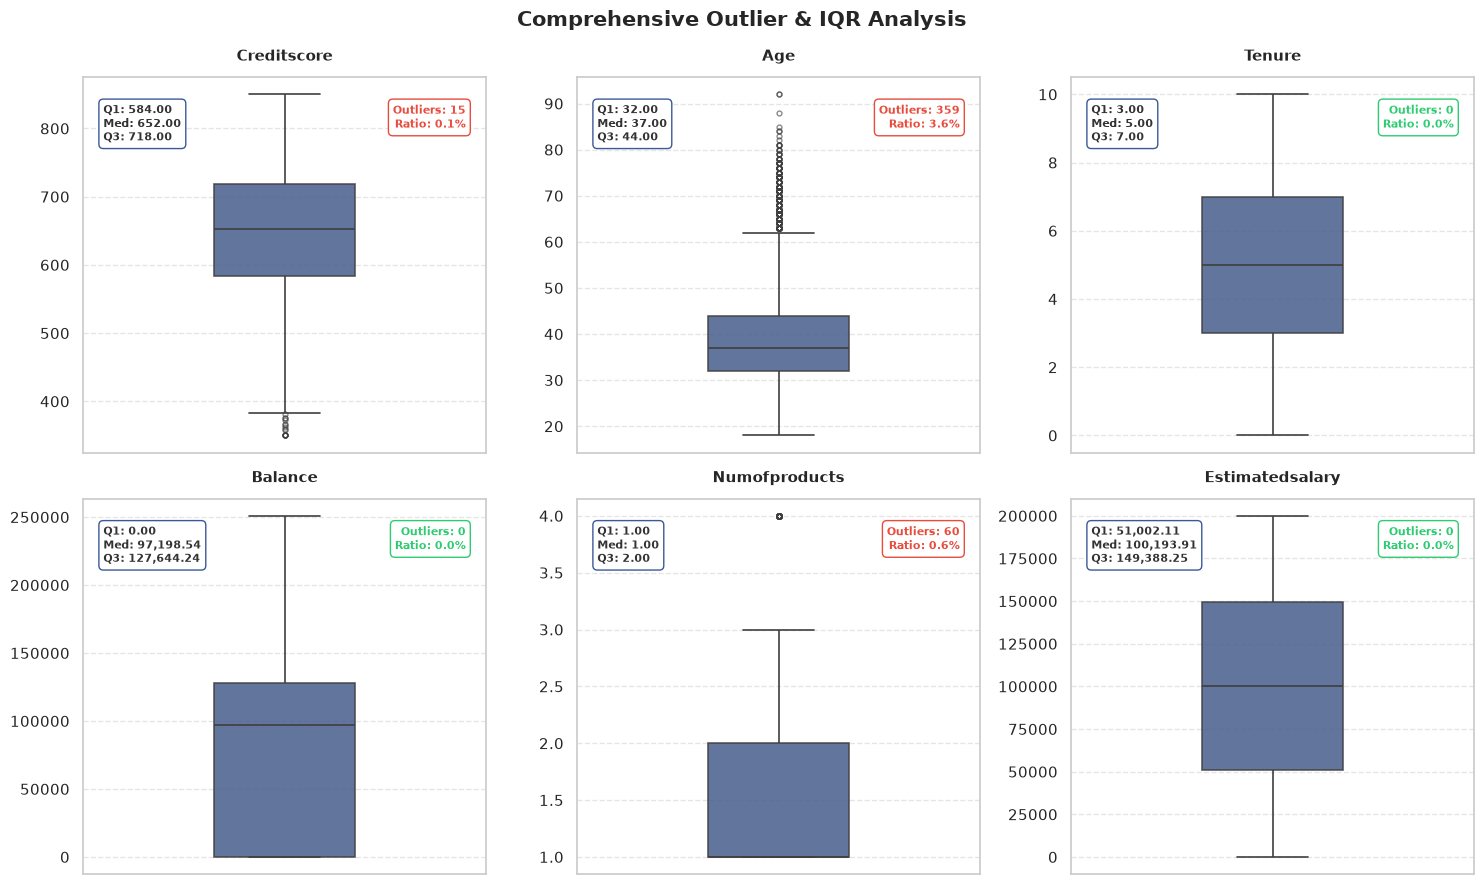

In [9]:
outlier_summary = []

for feature in numeric_features:
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]

    outlier_summary.append({
        "feature": feature,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": len(outliers),
        "outlier_percentage": (len(outliers) / len(df)) * 100
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
print("--- Outlier Summary (IQR Method) ---")
display(outlier_summary_df)


def visualize_outlier_dashboard(data_frame: pd.DataFrame, features: List[str]) -> None:
    """
    Menampilkan dashboard boxplot & analisis outlier untuk fitur numerik.
    """
    num_plots = len(features)
    cols = 3
    rows = (num_plots + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4.5))
    axes = axes.flatten() if num_plots > 1 else np.array([axes])

    for i, feature in enumerate(features):
        ax = axes[i]
        data = data_frame[feature].dropna()

        q1 = data.quantile(0.25)
        q3 = data.quantile(0.75)
        med = data.median()
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outliers = data[(data < lower_bound) | (data > upper_bound)]
        num_outliers = len(outliers)
        ratio = (num_outliers / len(data)) * 100 if len(data) > 0 else 0

        # Plot Boxplot
        sns.boxplot(
            y=data,
            ax=ax,
            color="#3b5998",
            width=0.35,
            linewidth=1.2,
            fliersize=3.5,
            boxprops=dict(alpha=0.85),
            flierprops=dict(marker="o", color="#e74c3c", alpha=0.6, markersize=3.5)
        )

        # Badge Statistik IQR (Kiri Atas)
        stats_bbox = dict(boxstyle="round,pad=0.4", fc="white", ec="#3b5998", lw=1)
        ax.text(
            0.05, 0.93,
            f"Q1: {q1:,.2f}\nMed: {med:,.2f}\nQ3: {q3:,.2f}",
            transform=ax.transAxes, ha="left", va="top", bbox=stats_bbox,
            color="#333333", fontsize=8, weight="bold"
        )

        # Badge Outlier (Kanan Atas)
        outlier_color = "#e74c3c" if num_outliers > 0 else "#2ecc71"
        outlier_bbox = dict(boxstyle="round,pad=0.4", fc="white", ec=outlier_color, lw=1)
        ax.text(
            0.95, 0.93,
            f"Outliers: {num_outliers:,}\nRatio: {ratio:.1f}%",
            transform=ax.transAxes, ha="right", va="top", bbox=outlier_bbox,
            color=outlier_color, fontsize=8, weight="bold"
        )

        # Formatting Visual
        ax.set_title(f"{feature.replace('_', ' ').title()}", fontsize=11, weight="bold", pad=12)
        ax.set_ylabel("")
        ax.grid(axis="y", linestyle="--", alpha=0.5)
        ax.grid(axis="x", visible=False)

    # Hapus axis kosong jika grid tidak penuh
    for j in range(num_plots, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Comprehensive Outlier & IQR Analysis", fontsize=15, weight="bold")
    plt.tight_layout()
    plt.show()


# Jalankan Dashboard Outlier
visualize_outlier_dashboard(df, numeric_features)

In [10]:
target_counts = df["Exited"].value_counts()
target_ratios = df["Exited"].value_counts(normalize=True) * 100

print(f"Jumlah Retained (0): {target_counts[0]:,} ({target_ratios[0]:.2f}%)")
print(f"Jumlah Churned  (1): {target_counts[1]:,} ({target_ratios[1]:.2f}%)")

Jumlah Retained (0): 7,963 (79.63%)
Jumlah Churned  (1): 2,037 (20.37%)


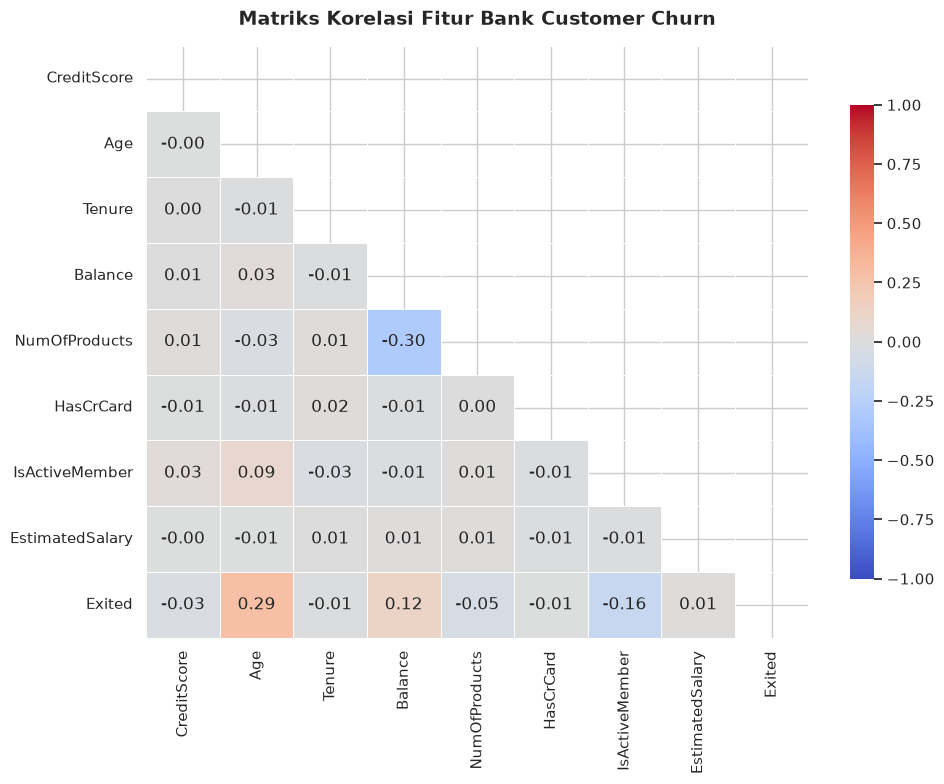

In [11]:
# Correlation Matrix Heatmap

# Select fitur numerik dan target label untuk analisis korelasi
corr_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
    "Exited"
]

plt.figure(figsize=(10, 8))

# Perhitungan Matriks Korelasi Pearson
corr_matrix = df[corr_features].corr()

# Mask untuk menyembunyikan segitiga atas (menghindari redundansi visual)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot Heatmap Korelasi
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot=True,         
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Matriks Korelasi Fitur Bank Customer Churn", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

In [12]:
# Menghapus kolom metadata/ID yang tidak memiliki bobot prediktif
cols_to_drop = ["RowNumber", "CustomerId", "Surname"]
df_cleaned = df.drop(columns=cols_to_drop)

# Separasi variabel prediktor (X) dan target label (y)
X = df_cleaned.drop(columns=["Exited"])
y = df_cleaned["Exited"]

print(f"Ukuran X (Fitur) : {X.shape[0]:,} baris x {X.shape[1]} kolom")
print(f"Ukuran y (Target): {y.shape[0]:,} baris")

Ukuran X (Fitur) : 10,000 baris x 10 kolom
Ukuran y (Target): 10,000 baris


In [13]:
# Train-Test Split

# Menggunakan stratify=y untuk menjaga proporsi imbalans (80:20) pada train & test set
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Jumlah Data Latih (X_train): {X_train.shape[0]:,} baris")
print(f"Jumlah Data Uji   (X_test) : {X_test.shape[0]:,} baris")
print("\nProporsi Target pada Train Set:")
print(y_train.value_counts(normalize=True).round(4) * 100)

Jumlah Data Latih (X_train): 8,000 baris
Jumlah Data Uji   (X_test) : 2,000 baris

Proporsi Target pada Train Set:
Exited
0    79.62
1    20.37
Name: proportion, dtype: float64


In [14]:
# Log Transformation (Fixing High Skewness)

# Membuat copy eksplisit untuk menghindari SettingWithCopyWarning
X_train = X_train.copy()
X_test = X_test.copy()

# Transformasi Log (np.log1p) pada fitur Age yang memiliki skewness 1.01
X_train["Age"] = np.log1p(X_train["Age"])
X_test["Age"] = np.log1p(X_test["Age"])

print(f"Skewness Age sebelum transformasi : 1.0113")
print(f"Skewness Age setelah transformasi (Train Set): {X_train['Age'].skew():.4f}")

Skewness Age sebelum transformasi : 1.0113
Skewness Age setelah transformasi (Train Set): 0.2233


In [15]:
# Encoding Categorical Features

categorical_cols = ["Geography", "Gender"]

# drop="first" digunakan untuk mencegah dummy variable trap (multicollinearity)
ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="error")

# Fit HANYA pada X_train, lalu transform pada X_train & X_test
encoded_train = ohe.fit_transform(X_train[categorical_cols])
encoded_test = ohe.transform(X_test[categorical_cols])

# Membuat DataFrame dari hasil encoding
encoded_cols = ohe.get_feature_names_out(categorical_cols)
df_encoded_train = pd.DataFrame(encoded_train, columns=encoded_cols, index=X_train.index)
df_encoded_test = pd.DataFrame(encoded_test, columns=encoded_cols, index=X_test.index)

# Penggabungan kembali ke DataFrame utama & menghapus kolom kategorikal lama
X_train = pd.concat([X_train.drop(columns=categorical_cols), df_encoded_train], axis=1)
X_test = pd.concat([X_test.drop(columns=categorical_cols), df_encoded_test], axis=1)

print("Kategorikal fitur berhasil di-encode. Kolom baru yang terbentuk:")
print(list(encoded_cols))

Kategorikal fitur berhasil di-encode. Kolom baru yang terbentuk:
['Geography_Germany', 'Geography_Spain', 'Gender_Male']


In [16]:
# Feature Scaling

# Kolom numerik murni yang membutuhkan standarisasi
scaling_cols = [
    "CreditScore", 
    "Age", 
    "Tenure", 
    "Balance", 
    "NumOfProducts", 
    "EstimatedSalary"
]

scaler = StandardScaler()

# Fit HANYA pada X_train, transform pada X_train & X_test
X_train[scaling_cols] = scaler.fit_transform(X_train[scaling_cols])
X_test[scaling_cols] = scaler.transform(X_test[scaling_cols])

In [17]:
# Verification & Data Summary

print("--- PREPROCESSING COMPLETED ---")
print(f"X_train Final Shape : {X_train.shape}")
print(f"X_test Final Shape  : {X_test.shape}")
print(f"Jumlah Missing Value: {X_train.isnull().sum().sum()}")
print("\nTampilan 5 baris pertama X_train:")
display(X_train.head())

--- PREPROCESSING COMPLETED ---
X_train Final Shape : (8000, 11)
X_test Final Shape  : (2000, 11)
Jumlah Missing Value: 0

Tampilan 5 baris pertama X_train:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
2151,1.058568,1.609632,0.684723,-1.226059,-0.910256,1,0,1.042084,0.0,0.0,1.0
8392,0.913626,-0.630563,-0.696202,0.413288,-0.910256,1,0,-0.623556,1.0,0.0,1.0
5006,1.079274,-0.070138,-1.731895,0.601687,0.808830,1,1,0.308128,1.0,0.0,0.0
4117,-0.929207,-0.070138,-0.005739,-1.226059,0.808830,1,0,-0.290199,0.0,0.0,1.0
7182,0.427035,1.020044,0.339492,0.548318,0.808830,0,1,0.135042,1.0,0.0,1.0


In [18]:
# Buat folder penyimpanan
output_dir = 'churn_preprocessing'
os.makedirs(output_dir, exist_ok=True)

# Simpan hasil preprocessing ke format CSV
X_train.to_csv(f'{output_dir}/X_train.csv', index=False)
X_test.to_csv(f'{output_dir}/X_test.csv', index=False)
y_train.to_csv(f'{output_dir}/y_train.csv', index=False)
y_test.to_csv(f'{output_dir}/y_test.csv', index=False)